# Agentic RAG with LangGraph

In [2]:
import os
from typing import List, TypedDict
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_groq import ChatGroq
from langchain_community.embeddings import FakeEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

In [3]:
from dotenv import load_dotenv
load_dotenv()

True

In [8]:
# Set your API keys in the .env file
openai_api_key = os.getenv("OPENAI_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"] = openai_api_key
os.environ["GROQ_API_KEY"] = groq_api_key

# Initialize models
# llm = ChatOpenAI(model="gpt-4.1", temperature=0)
llm = ChatGroq(groq_api_key=groq_api_key, model_name="openai/gpt-oss-safeguard-20b", temperature=0.1, max_tokens=1024)
# embeddings = OpenAIEmbeddings()
# FakeEmbeddings generates random vectors - fine for learning the RAG pipeline
# Replace with a real embeddings model (e.g. OpenAIEmbeddings) in production
embeddings = FakeEmbeddings(size=384)

In [9]:
llm

ChatGroq(output_version=None, profile={}, client=<groq.resources.chat.completions.Completions object at 0x0000010C641279D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000010C641F07D0>, model_name='openai/gpt-oss-safeguard-20b', temperature=0.1, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None, max_tokens=1024)

# State Definition

In [10]:
class AgentState(TypedDict):
    question: str
    documents: List[Document]
    answer: str
    needs_retrieval: bool

In [11]:
### Sample Document and Vector Store 
# Sample documents for demnstration
sample_texts = [
  "LangGraph is a framework for building agentic applications with LLMs. It provides a structured way to define states, actions, and transitions for agents, allowing them to interact with their environment and make decisions based on their goals.",
  "RAG (Retrieval-Augmented Generation) is a technique that combines retrieval of relevant documents with generation capabilities of LLMs. It allows models to access external knowledge sources, improving their ability to answer questions and generate content based on up-to-date information.",
  "Vector databases store embeddings of documents, enabling efficient similarity search. They are essential for RAG systems to quickly retrieve relevant information based on the semantic content of queries and documents.",
  "FAISS is a popular library for efficient similarity search and clustering of dense vectors. It is widely used in RAG systems to manage and query large collections of document embeddings, enabling fast retrieval of relevant information based on vector similarity.",
  "Agentic systems are AI systems that can autonomously perform tasks, make decisions, and interact with their environment to achieve specific goals. They often leverage LLMs for reasoning and decision-making, and can be enhanced with RAG techniques to access external knowledge sources for improved performance."
]

# Create documents 
documents = [Document(page_content=text) for text in sample_texts]

## Create vector store
vectorestore = FAISS.from_documents(documents, embeddings)
retriever = vectorestore.as_retriever(k=3)

# Agents function

In [12]:
def decide_retrieval(state: AgentState) -> AgentState:
    """Decide whether to perform retrieval based on the question."""
    question = state["question"]

    # Simple heuristic: if we already have an answer, no need to retrieve
    retrival_keywords = ["what", "who", "when", "where", "why", "how", "explain", "describe", "list", "define", "compare", "contrast", "tell me", "give me", "show me", "find", "search", "lookup", "summarize", "analyze", "interpret", "evaluate", "assess", "recommend", "suggest", "propose", "predict", "forecast", "identify", "categorize", "classify", "differentiate", "distinguish", "relate", "connect", "associate", "correlate", "infer", "deduce", "reason", "argue", "debate", "discuss" ]
    needs_retrieval = any(keyword in question.lower() for keyword in retrival_keywords)

    return {**state, "needs_retrieval": needs_retrieval}

In [13]:
def retrieve_documents(state: AgentState) -> AgentState:
    """Retrieve relevant documents based on the question."""
    question = state["question"]
    documents = retriever.invoke(question)
    return {**state, "documents": documents}

In [14]:
def generate_answer(state: AgentState) -> AgentState:
    """
    Generate an answer based on the question and retrieved documents, or direct response.
    """
    
    question = state["question"]
    documents = state.get("documents", [])

    if documents:
        #RAG approach: use documtents as context for answer generation
        context = "\n\n".join(doc.page_content for doc in documents)
        prompt = f"""Based on the following context, answer the question:

Context:{context}
Question: {question}
Answer:"""
    else:
        #Direct response without retrieval
        prompt = f"Answer the following question: {question}"

    response = llm.invoke(prompt)
    answer = response.content
    
    return {**state, "answer": answer}

# Conditional Logic

In [15]:
def should_retrieve(state: AgentState) -> str:
    """Determine the next step based on whether retrieval is needed."""
    if state["needs_retrieval"]:
        return "retrieve"
    else:
        return "generate"

# Build the Graph

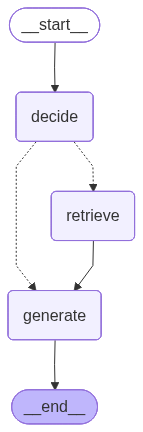

In [18]:
# Create the state graph
workflow = StateGraph(AgentState)

# Add notes
workflow.add_node("decide", decide_retrieval)
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("generate", generate_answer)

# Set entry point
workflow.set_entry_point("decide")

# Add conditional edges
workflow.add_conditional_edges(
    "decide",
    should_retrieve,
    {
        "retrieve": "retrieve",
        "generate": "generate"
    }
)

# Add edges
workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)

# Compile the graph
app = workflow.compile()
app

# Test the Agentic System

In [27]:
def ask_question(question: str) -> str:
    """Run the agentic RAG system to answer a question."""
    initial_state = AgentState(
        question=question,
        documents=[],
        answer="",
        needs_retrieval=False
    )
    result = app.invoke(initial_state)
    return result

In [28]:
# Test the agent with a sample question
question1 = "What is LangGraph and how does it relate to RAG?"
result1 = ask_question(question1)
result1

{'question': 'What is LangGraph and how does it relate to RAG?',
 'documents': [Document(id='b2a6c5e0-96d1-4025-8ff2-c75bc318dcc4', metadata={}, page_content='FAISS is a popular library for efficient similarity search and clustering of dense vectors. It is widely used in RAG systems to manage and query large collections of document embeddings, enabling fast retrieval of relevant information based on vector similarity.'),
  Document(id='1ab19a3f-cdb2-4375-b795-2103cc4a0a5c', metadata={}, page_content='RAG (Retrieval-Augmented Generation) is a technique that combines retrieval of relevant documents with generation capabilities of LLMs. It allows models to access external knowledge sources, improving their ability to answer questions and generate content based on up-to-date information.'),
  Document(id='f3669f53-9625-4a93-b723-d8916a5f57c2', metadata={}, page_content='Agentic systems are AI systems that can autonomously perform tasks, make decisions, and interact with their environment t

In [29]:
# Test another question
question2 = "How does FAISS enable efficient retrieval in RAG systems?"
result2 = ask_question(question2)

print(f"Question: {question2}")
print(f"Retrieved documents: {len(result2['documents'])}")
print(f"Answer: {result2['answer']}")
print("\n" + "-"*50 + "\n")

Question: How does FAISS enable efficient retrieval in RAG systems?
Retrieved documents: 4
Answer: FAISS speeds up RAG by indexing the dense embeddings of all documents and then performing fast approximate‑nearest‑neighbor (ANN) searches.  
- It builds compact, multi‑level index structures (IVF, HNSW, PQ, etc.) that reduce the search space dramatically.  
- The indices can be stored on CPU or GPU, allowing sub‑millisecond lookups even for millions of vectors.  
- When a query is encoded into a vector, FAISS quickly returns the top‑k most similar document embeddings, which the RAG system then uses to fetch or synthesize the relevant content.  

In short, FAISS turns a large set of embeddings into a highly efficient similarity search engine, making real‑time retrieval in RAG pipelines practical.

--------------------------------------------------

